In [1]:
import numpy as np
import xarray as xr
from matplotlib import pyplot as plt
import pandas as pd
from fonts_config import set_computer_modern, truncate_colormap
set_computer_modern()
import matplotlib as mpl
mpl.rcParams['axes.unicode_minus'] = False
import matplotlib.lines as mlines
from matplotlib.patches import Rectangle, Patch
import glob
import os
from matplotlib.legend_handler import HandlerTuple
import matplotlib.ticker as ticker

from matplotlib import cm
import matplotlib.colors as mcolors


In [2]:
# ----------------------------------------------------------------------------
# Paths
# ----------------------------------------------------------------------------
sims=xr.open_dataset("../output/timeseries_from1D.nc")
temp=xr.open_dataset("../output/timeseries_from2D.nc")
leger=xr.open_dataset("../../FesmData/Leger2024_PaleoGris/output/regions_area_paleogris.nc")
scores = xr.open_dataset("../scoring/scores/scores2.nc")
n_best=2572
best=sims.sel(sim=n_best)
T_srf_best=temp.sel(sim=n_best)
# Observations
A_obs=1.7
V_obs=7.4
#scores
S = xr.open_dataset("../scoring/scores/scores2.nc")

In [3]:
v_wm = (scores.S * sims.V_sle).sum(dim="sim")/scores.S.sum(dim="sim")
a_wm = (scores.S * sims.A_ice_g).sum(dim="sim")/scores.S.sum(dim="sim")

In [4]:
def calc_std (esl, weighted_mean,scores):
    upper_std = np.zeros_like(weighted_mean)
    lower_std = np.zeros_like(weighted_mean)

    for t in range(esl.shape[1]):
        diff = esl[:, t] - weighted_mean[t]
        
        # Máscaras para separar arriba y abajo de la media
        mask_upper = diff > 0
        mask_lower = diff < 0
        
        # Desviación superior: RMS ponderado de las diferencias positivas
        if np.any(mask_upper):
            var_upper = np.sum(scores[mask_upper] * (diff[mask_upper]**2)) / np.sum(scores[mask_upper])
            upper_std[t] = np.sqrt(var_upper)
            
        # Desviación inferior: RMS ponderado de las diferencias negativas
        if np.any(mask_lower):
            var_lower = np.sum(scores[mask_lower] * (diff[mask_lower]**2)) / np.sum(scores[mask_lower])
            lower_std[t] = np.sqrt(var_lower)
    return upper_std, lower_std

v_upper_std, v_lower_std = calc_std(sims.V_sle.values,v_wm.values,scores.S)
a_upper_std, a_lower_std = calc_std(sims.A_ice_g.values,a_wm.values,scores.S)

/tmp/ipykernel_164980/1234731132.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


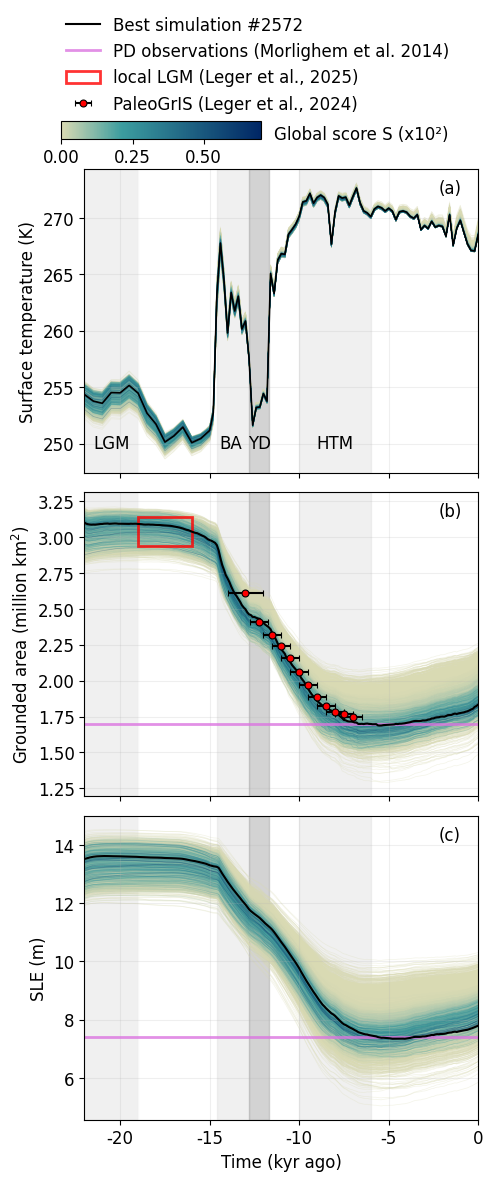

In [ ]:
#plot en horizontal y con periodos
s_values = S.S.values 
colors = ["#D9DAB3", "#3C9D9F", "#002665"]
nodes = [0, 0.3, 1.0]
cmap = mcolors.LinearSegmentedColormap.from_list("custom_warm", list(zip(nodes, colors)))
sorted_sim_indices = S.sim.sortby(S.S).values
norm = mcolors.Normalize(vmin=s_values.min()*100, vmax=s_values.max()*100)

fig, axs = plt.subplots(3, 1, figsize=(5, 12),sharex=True)

for index in sorted_sim_indices:
    sim = sims.sel(sim=index)
    t_sim = temp.sel(sim=index) # Asumiendo correspondencia de índices
    color_s = cmap(norm(S.S.sel(sim=index).values*100))
    
    # Plot Temp
    axs[0].plot(t_sim.time/1e3, t_sim.T_ann, color=color_s, alpha=0.3, linewidth=0.5, zorder=1)
    
    # Plot Area
    axs[1].plot(sim.time/1e3, sim.A_ice_g, color=color_s, alpha=0.3, linewidth=0.5, zorder=1)
    
    # Plot Volume
    axs[2].plot(sim.time/1e3, sim.V_sle, color=color_s, alpha=0.3, linewidth=0.5, zorder=1)


axs[0].plot(T_srf_best.time/1e3, T_srf_best.T_ann, color='black', linewidth=1.2, zorder=10)
axs[1].plot(best.time/1e3, best.A_ice_g, color='black', linewidth=1.5, zorder=10)
axs[2].plot(best.time/1e3, best.V_sle, color='black', linewidth=1.5, zorder=10)

present = axs[1].axhline(y=A_obs, color='#DB74E0', linestyle='-', alpha=0.8, linewidth=2, zorder=2)
rect = Rectangle((-19, 2.94), 3, 0.2, facecolor="none", edgecolor='red', linewidth=2,alpha=0.8, zorder=4)
axs[1].add_patch(rect)
paleogris = axs[1].errorbar(-leger["time"][1:] * 1e-3, leger.tot[1:], xerr=leger.time_err[1:]*1e-3, 
                            fmt='o', ecolor='black', markersize=5, markerfacecolor='red', 
                            markeredgecolor='black', markeredgewidth=0.8, capsize=2, zorder=10)

axs[2].axhline(y=V_obs, color="#DB74E0", linestyle='-', alpha=0.8, linewidth=2, zorder=2)
# periodos
axs[0].text(-20.5, 250, "LGM", ha="center", va="center")
axs[0].text(-13.8, 250, "BA",  ha="center", va="center")
axs[0].text(-12.2, 250, "YD",  ha="center", va="center")
axs[0].text(-8, 250, "HTM",  ha="center", va="center")

# --- Estética de los ejes ---
axs[0].set_ylabel('Surface temperature (K)')
axs[1].set_ylabel('Grounded area (million km$^2$)')
axs[2].set_ylabel('SLE (m)')
axs[2].set_xlabel('Time (kyr ago)')
for i, ax in enumerate(axs):
    ax.grid(alpha=0.2, zorder=0)
    ax.set_xlim(-22, 0)
    ax.text(0.9, 0.92, f'({chr(97+i)})', transform=ax.transAxes)
    ax.axvspan(-22, -19, color="#e2e2e2", alpha=0.5,zorder=0)   # azul muy claro
    ax.axvspan(-19, -14.8, color="white", alpha=0.5,zorder=0)   # azul claro
    ax.axvspan(-14.6, -12.8, color="#e2e2e2", alpha=0.5,zorder=0)   # azul muy claro
    ax.axvspan(-12.8, -11.7, color="#a8a8a8", alpha=0.5,zorder=0)   # azul algo más oscuro
    ax.axvspan(-10, -6, color="#e2e2e2", alpha=0.5,zorder=0)   # azul muy claro

# --- Leyenda personalizada ---
h_list, l_list = [], []
best_line = mlines.Line2D([], [], color='black', linewidth=1.5)
# Representación del ensemble en la leyenda con un color intermedio del colormap
ensemble_sample = mlines.Line2D([], [], color=cmap(0.5), alpha=0.5, linewidth=1)

h_list = [best_line, present, rect, paleogris]
l_list = [f'Best simulation #{n_best}', 
          'PD observations (Morlighem et al. 2014)', 'local LGM (Leger et al., 2025)', 
          'PaleoGrIS (Leger et al., 2024)']

leg = fig.legend(h_list, l_list, frameon=False, loc='upper left', ncol=1, bbox_to_anchor=(0.1, 0.99))
leg.get_frame().set_linewidth(0)

cbar_ax = fig.add_axes([0.12, 0.875, 0.4, 0.015])
fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), cax=cbar_ax)
cb = fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), cax=cbar_ax, orientation='horizontal')
cb.set_label('Global score S (x10²)', labelpad=-30, x=1.5)

plt.tight_layout()
plt.subplots_adjust(top=0.85) # Aumentado para que quepa la leyenda de 3 filas
plt.show()

fig.savefig(f"../figs_final/fig2_{n_best}ensemble_timeseries.png", dpi=300)

<>:76: SyntaxWarning: invalid escape sequence '\c'
<>:76: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_2452028/903888042.py:76: SyntaxWarning: invalid escape sequence '\c'
  cb.set_label('Ensemble members S ($\cdot 10^{-2}$)')
/tmp/ipykernel_2452028/903888042.py:78: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


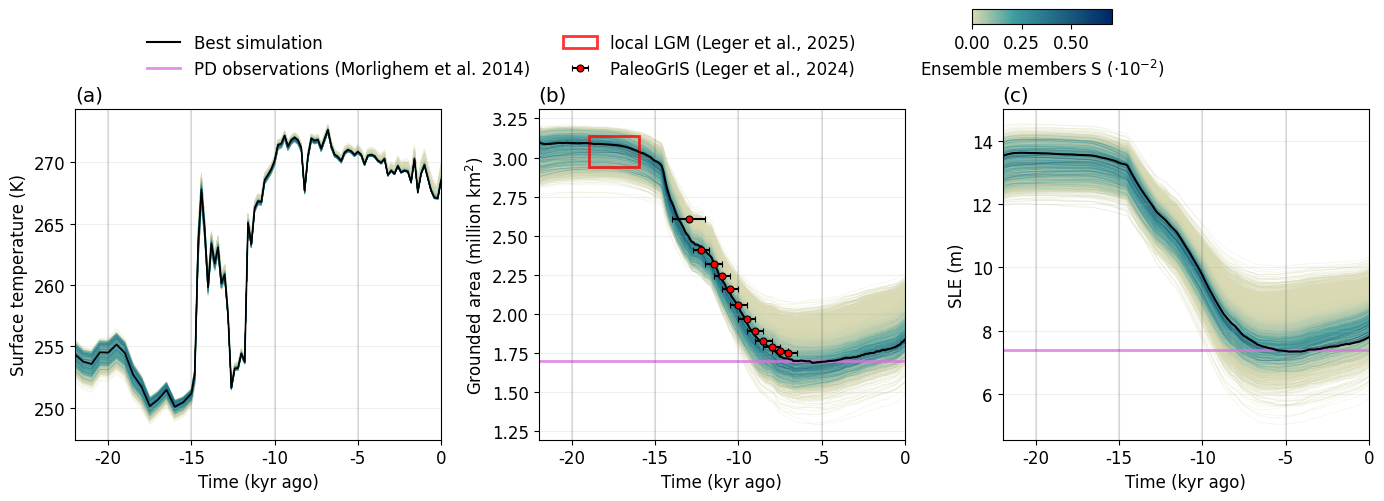

In [ ]:
#plot en horizontal

s_values = S.S.values 
colors = ["#D9DAB3", "#3C9D9F", "#002665"]
nodes = [0, 0.3, 1.0]
cmap = mcolors.LinearSegmentedColormap.from_list("custom_warm", list(zip(nodes, colors)))
sorted_sim_indices = S.sim.sortby(S.S).values
norm = mcolors.Normalize(vmin=s_values.min()*100, vmax=s_values.max()*100)

fig, axs = plt.subplots(1, 3, figsize=(14, 5))

# 2. Plot de los miembros del ensemble usando el color de S
for index in sorted_sim_indices:
    sim = sims.sel(sim=index)
    t_sim = temp.sel(sim=index) # Asumiendo correspondencia de índices
    color_s = cmap(norm(S.S.sel(sim=index).values*100))
    
    # Plot Temp
    axs[0].plot(t_sim.time/1e3, t_sim.T_ann, color=color_s, alpha=0.3, linewidth=0.5, zorder=1)
    
    # Plot Area
    axs[1].plot(sim.time/1e3, sim.A_ice_g, color=color_s, alpha=0.3, linewidth=0.5, zorder=1)
    
    # Plot Volume
    axs[2].plot(sim.time/1e3, sim.V_sle, color=color_s, alpha=0.3, linewidth=0.5, zorder=1)

# 3. Plot de la mejor simulación (Best) - Manteniendo negro para resaltar
axs[0].plot(T_srf_best.time/1e3, T_srf_best.T_ann, color='black', linewidth=1.2, zorder=10)
axs[1].plot(best.time/1e3, best.A_ice_g, color='black', linewidth=1.5, zorder=10)
axs[2].plot(best.time/1e3, best.V_sle, color='black', linewidth=1.5, zorder=10)

# --- Elementos de referencia y observaciones ---
present = axs[1].axhline(y=A_obs, color='#DB74E0', linestyle='-', alpha=0.8, linewidth=2, zorder=2)
rect = Rectangle((-19, 2.94), 3, 0.2, facecolor="none", edgecolor='red', linewidth=2,alpha=0.8, zorder=4)
axs[1].add_patch(rect)
paleogris = axs[1].errorbar(-leger["time"][1:] * 1e-3, leger.tot[1:], xerr=leger.time_err[1:]*1e-3, 
                            fmt='o', ecolor='black', markersize=5, markerfacecolor='red', 
                            markeredgecolor='black', markeredgewidth=0.8, capsize=2, zorder=10)

axs[2].axhline(y=V_obs, color="#DB74E0", linestyle='-', alpha=0.8, linewidth=2, zorder=2)

# --- Estética de los ejes ---
axs[0].set_ylabel('Surface temperature (K)')
axs[1].set_ylabel('Grounded area (million km$^2$)')
axs[2].set_ylabel('SLE (m)')

for i, ax in enumerate(axs):
    ax.set_xlabel('Time (kyr ago)')
    ax.grid(alpha=0.2, zorder=0)
    for v in [-20, -15, -10, -5]:
        ax.axvline(x=v, color='black', linestyle='-', alpha=0.1)
    ax.set_xlim(-22, 0)
    ax.set_title(f'({chr(97+i)})', loc='left')

# --- Leyenda personalizada ---
h_list, l_list = [], []
best_line = mlines.Line2D([], [], color='black', linewidth=1.5)
# Representación del ensemble en la leyenda con un color intermedio del colormap
ensemble_sample = mlines.Line2D([], [], color=cmap(0.5), alpha=0.5, linewidth=1)

h_list = [best_line, present, rect, paleogris]
l_list = ['Best simulation', 
          'PD observations (Morlighem et al. 2014)', 'local LGM (Leger et al., 2025)', 
          'PaleoGrIS (Leger et al., 2024)']

leg = fig.legend(h_list, l_list, frameon=False, loc='upper left', ncol=2, bbox_to_anchor=(0.1, 0.98))
leg.get_frame().set_linewidth(0)

cbar_ax = fig.add_axes([0.7, 0.97, 0.1, 0.03])
fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), cax=cbar_ax)
cb = fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), cax=cbar_ax, orientation='horizontal')
cb.set_label('Ensemble members S ($\cdot 10^{-2}$)')

plt.tight_layout()
plt.subplots_adjust(top=0.8) # Aumentado para que quepa la leyenda de 3 filas
plt.show()

In [5]:
fig.savefig(f"../figs_final/{n_best}_timeseries.png", dpi=300)


In [13]:
ds_areas=temp
dt = np.gradient(best.time) 
time_1d = best.time.values / 1e3  # Tiempo en kyr para que la derivada sea /kyr
time_2d = ds_areas.time.values / 1e3  # Tiempo en kyr para que la derivada sea /kyr
region_names = ["NW", "W", "SW","SE","E","NE","N"]

dTemp = np.gradient(temp.T_ann.sel(sim=n_best).values, time_2d)
umbral_rate = 10  # K por milenio
mask = (dTemp) > umbral_rate 
diff = np.diff(mask.astype(int))
starts = np.where(diff == 1)[0]
ends = np.where(diff == -1)[0]
if mask[0]: starts = np.insert(starts, 0, 0)
if mask[-1]: ends = np.append(ends, len(mask)-1)

mask2 = (dTemp) < -umbral_rate 
diff2 = np.diff(mask2.astype(int))
starts2 = np.where(diff2 == 1)[0]
ends2 = np.where(diff2 == -1)[0]
if mask2[0]: starts2 = np.insert(starts2, 0, 0)
if mask2[-1]: ends2 = np.append(ends2, len(mask2)-1)

dVol  = np.gradient(best.V_sle.values, time_1d)
u2 = -0.8  # K por milenio
mask_vol = (dVol) < u2 
diff_vol = np.diff(mask_vol.astype(int))
starts_vol = np.where(diff_vol == 1)[0]
ends_vol = np.where(diff_vol == -1)[0]
if mask_vol[0]: starts_vol = np.insert(starts_vol, 0, 0)
if mask_vol[-1]: ends_vol = np.append(ends_vol, len(mask_vol)-1)

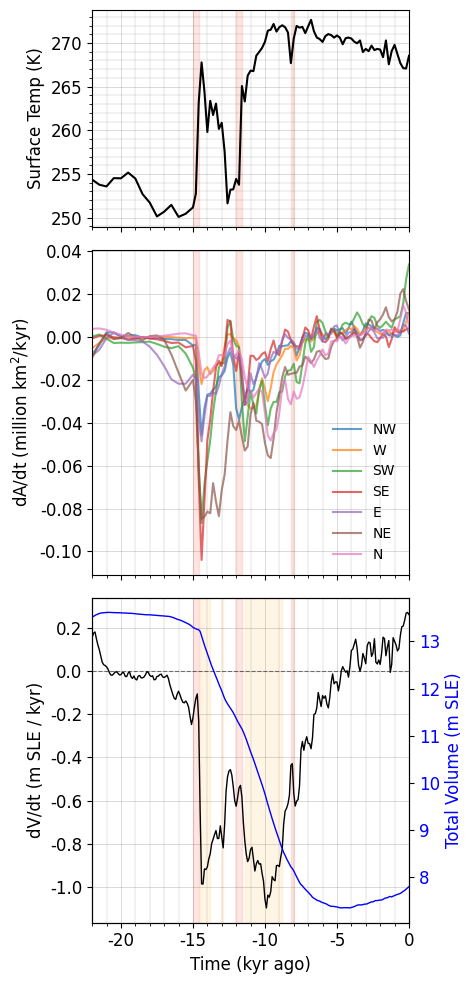

In [14]:

dArea = np.gradient(best.A_ice_g.values, time_1d)


fig, axs = plt.subplots(3, 1, figsize=(5, 10), height_ratios=[2,3,3],sharex=True)

# --- AX 0: TEMPERATURA Y SU DERIVADA ---
l1, = axs[0].plot(time_2d, T_srf_best.T_ann, color='black', label='T Surface')
axs[0].set_ylabel('Surface Temp (K)')

# axs[1].plot(time_1d, dArea, color='black', linewidth=2, label='Total Grounded Area')

# Colores para regiones (ajusta según cuántas tengas)
region_colors = plt.cm.tab10(np.linspace(0, 1, len(ds_areas.region)))

for i, reg in enumerate(region_ids):
    # Extraemos la serie temporal de la región para la simulación 'best'
    # Ajusta la selección según cómo esté indexado tu ds_areas
    area_reg = ds_areas.sel(region=reg, sim=n_best).A # o el nombre de tu variable
    dArea_reg = np.gradient(area_reg, time_2d)
    axs[1].plot(time_2d, dArea_reg, label=f'{region_names[i]}', alpha=0.7)

axs[1].set_ylabel('dA/dt (million km$^2$/kyr)')
axs[1].legend(fontsize='small', frameon=False, loc='lower right')

# --- AX 2: DERIVADA DEL VOLUMEN (SLE) ---
axs[2].plot(time_1d, dVol, color='black', linewidth=1)
# Añadimos una línea horizontal en 0 para ver cuándo crece y cuándo encoge
axs[2].axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
axs[2].set_ylabel('dV/dt (m SLE / kyr)')
ax2_twin = axs[2].twinx()
l_vtot, = ax2_twin.plot(time_1d, best.V_sle, color='blue', linestyle='-', linewidth=1, label='Total Volume')
ax2_twin.set_ylabel('Total Volume (m SLE)', color='blue')
ax2_twin.tick_params(axis='y', labelcolor='blue')

for s, e in zip(starts_vol, ends_vol):
    axs[2].axvspan(time_1d[s], time_1d[e], color='orange', alpha=0.1, 
                label='Abrupt Change' if ax==axs[2] and s==starts_vol[0] else "")
axs[2].set_xlabel('Time (kyr ago)')

# 3. Formato común
for ax in axs:
    ax.set_xlim(-22, 0)
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(1))
    ax.yaxis.set_minor_locator(ticker.MultipleLocator(1))
    ax.grid(which='minor', linestyle='-', linewidth=0.3, color='gray', alpha=0.5)
    ax.grid(which='major', linestyle='-', linewidth=0.5, color='black', alpha=0.2)
    for s, e in zip(starts, ends):
        ax.axvspan(time_2d[s], time_2d[e], color='salmon', alpha=0.2, 
                   label='Abrupt Change' if ax==axs[0] and s==starts[0] else "")
        

plt.tight_layout()
plt.show()

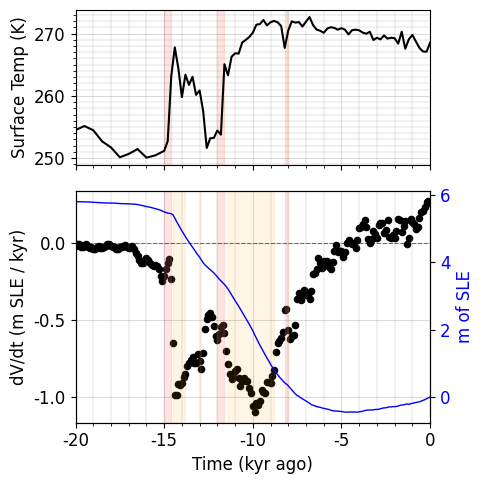

In [24]:
region_ids=leger.region.values

dArea = np.gradient(best.A_ice_g.values, time_1d)


fig, axs = plt.subplots(2, 1, figsize=(5, 5), height_ratios=[2,3],sharex=True)

# --- AX 0: TEMPERATURA Y SU DERIVADA ---
l1, = axs[0].plot(time_2d, T_srf_best.T_ann, color='black', label='T Surface')
axs[0].set_ylabel('Surface Temp (K)')


# --- AX 2: DERIVADA DEL VOLUMEN (SLE) ---
axs[1].scatter(time_1d, dVol, color='black',  marker='o', s=20)
# Añadimos una línea horizontal en 0 para ver cuándo crece y cuándo encoge
axs[1].axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
axs[1].set_ylabel('dV/dt (m SLE / kyr)')
ax2_twin = axs[1].twinx()
l_vtot, = ax2_twin.plot(time_1d, best.V_sle-best.V_sle[-1], color='blue', linestyle='-', linewidth=1, label='Total Volume')
ax2_twin.set_ylabel('m of SLE', color='blue')
ax2_twin.tick_params(axis='y', labelcolor='blue')

for s, e in zip(starts_vol, ends_vol):
    axs[1].axvspan(time_1d[s], time_1d[e], color='orange', alpha=0.1, 
                label='Abrupt Change' if ax==axs[1] and s==starts_vol[0] else "")
axs[1].set_xlabel('Time (kyr ago)')

# 3. Formato común
for ax in axs:
    ax.set_xlim(-22, 0)
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(1))
    ax.yaxis.set_minor_locator(ticker.MultipleLocator(1))
    ax.grid(which='minor', linestyle='-', linewidth=0.3, color='gray', alpha=0.5)
    ax.grid(which='major', linestyle='-', linewidth=0.5, color='black', alpha=0.2)
    for s, e in zip(starts, ends):
        ax.axvspan(time_2d[s], time_2d[e], color='salmon', alpha=0.2, 
                   label='Abrupt Change' if ax==axs[0] and s==starts[0] else "")
    ax.set_xlim(-20,0)

plt.tight_layout()
plt.show()

<>:40: SyntaxWarning: invalid escape sequence '\p'
<>:40: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_2546239/4072411434.py:40: SyntaxWarning: invalid escape sequence '\p'
  axs[4].fill_between(sims.time/1e3, a_bot, a_top, color='#48A373', alpha=0.3, zorder=1, label='$\pm$ 1 std')
/tmp/ipykernel_2546239/4072411434.py:19: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  rect = Rectangle((-19, 2.94), 3, 0.2, color='red', edgecolor="black", alpha=0.4)
/tmp/ipykernel_2546239/4072411434.py:40: SyntaxWarning: invalid escape sequence '\p'
  axs[4].fill_between(sims.time/1e3, a_bot, a_top, color='#48A373', alpha=0.3, zorder=1, label='$\pm$ 1 std')


NameError: name 'a_wm' is not defined

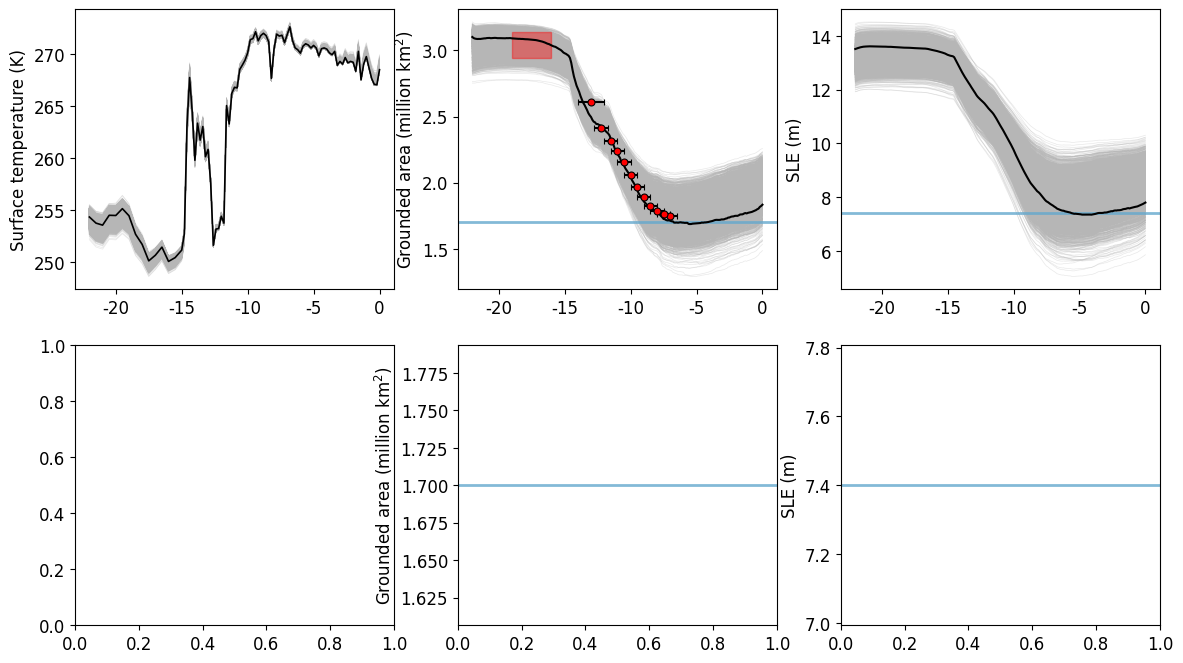

In [8]:
h_list, l_list = [], []

fig, axs = plt.subplots(2,3,figsize=(14,8))
axs = axs.flatten()
for index in sims.sim:
    sim=sims.sel(sim=index)
    axs[1].plot(sim.time/1e3, sim.A_ice_g, color='#b6b6b6',alpha=0.3, linewidth=0.5,zorder=1)
    axs[2].plot(sim.time/1e3, sim.V_sle, color='#b6b6b6',alpha=0.3, linewidth=0.5,zorder=1)

for index in temp.sim:
    T_srf= temp.sel(sim=index)
    axs[0].plot(T_srf.time/1e3, T_srf.T_ann, color='#b6b6b6',alpha=0.3, linewidth=0.5,zorder=1)
    # axs[0].plot(T_srf.time/1e3, T_srf.T_sum, color='orange',alpha=0.5, linewidth=0.5,zorder=1)

axs[0].plot(T_srf_best.time/1e3, T_srf_best.T_ann, color='black', linewidth=1.2,zorder=2)
axs[1].plot(best.time/1e3, best.A_ice_g, color='black', linewidth=1.5,zorder=3)
axs[2].plot(best.time/1e3, best.V_sle, color='black', linewidth=1.5,zorder=3)

rect = Rectangle((-19, 2.94), 3, 0.2, color='red', edgecolor="black", alpha=0.4)
lgm = axs[1].add_patch(rect)
paleogris = axs[1].errorbar(-leger["time"][1:] * 1e-3,leger.tot[1:],xerr=leger.time_err[1:]*1e-3,fmt='o',ecolor='black',
                markersize=5,markerfacecolor='red',markeredgecolor='black',markeredgewidth=0.8,
                capsize=2,zorder=4,label="Leger et al. (2024)")
axs[1].axhline(y=A_obs, color='#64A8CD', linestyle='-', alpha=0.8,linewidth=2,zorder=2)
axs[2].axhline(y=V_obs, color='#64A8CD' , linestyle='-', alpha=0.8,linewidth=2,zorder=2)

axs[4].axhline(y=A_obs, color='#64A8CD', linestyle='-', alpha=0.8,linewidth=2,zorder=2)
axs[5].axhline(y=V_obs, color='#64A8CD' , linestyle='-', alpha=0.8,linewidth=2,zorder=2)

axs[0].set_ylabel('Surface temperature (K)')
axs[1].set_ylabel('Grounded area (million km$^2$)')
axs[2].set_ylabel('SLE (m)')
axs[4].set_ylabel('Grounded area (million km$^2$)')
axs[5].set_ylabel('SLE (m)')

a_top = a_wm + a_upper_std
a_bot = a_wm - a_lower_std

axs[4].plot(sims.time/1e3, a_wm, color='#48A373', alpha=1, linewidth=1.5, zorder=3)
axs[4].fill_between(sims.time/1e3, a_bot, a_top, color='#48A373', alpha=0.3, zorder=1, label='$\pm$ 1 std')
axs[4].plot(sims.time/1e3, a_top, color='#48A373', linewidth=0.5, alpha=0.5, zorder=2)
axs[4].plot(sims.time/1e3, a_bot, color='#48A373', linewidth=0.5, alpha=0.5, zorder=2)

v_top = v_wm + v_upper_std
v_bot = v_wm - v_lower_std

fill = axs[5].plot(sims.time/1e3, v_wm, color='#48A373', alpha=1, linewidth=1.5, zorder=3)
axs[5].fill_between(sims.time/1e3, v_bot, v_top, color='#48A373', alpha=0.3, zorder=1)
axs[5].plot(sims.time/1e3, v_top, color='#48A373', linewidth=0.5, alpha=0.5, zorder=2)
axs[5].plot(sims.time/1e3, v_bot, color='#48A373', linewidth=0.5, alpha=0.5, zorder=2)
axs[4].plot(best.time/1e3, best.A_ice_g, color='black', linewidth=1.5,zorder=3)
axs[5].plot(best.time/1e3, best.V_sle, color='black', linewidth=1.5,zorder=3)

for ax in axs:
    if ax != axs[3]:
        ax.set_xlabel('Time (kyr ago)')
        ax.grid(alpha=0.2,zorder=2)
        ax.axvline(x=-20, color='black', linestyle='-', alpha=0.2)
        ax.axvline(x=-15, color='black', linestyle='-', alpha=0.2)
        ax.axvline(x=-10, color='black', linestyle='-', alpha=0.2)
        ax.axvline(x=-5, color='black', linestyle='-', alpha=0.2)
        ax.set_xlim(-22,0)
    
# Legend 
gray_line  = mlines.Line2D([], [], color='#b6b6b6',  alpha=0.8, linewidth=1)
best_line = mlines.Line2D([], [], color='black', linewidth=1.2)
wm = mlines.Line2D([], [], color='#48A373', linewidth=1.2)
for element in [best_line,gray_line,wm,present,lgm,paleogris]:
    h_list.append(element)

for element in ['Best simulation','Ensamble members','Weighted mean','PD observations (Morlighem et al. 2014)','local LGM (Leger et al., 2025)','PaleoGrIS (Leger et al., 2024)']:
    l_list.append(element)

axs[0].set_title('(a)',loc='left')
axs[1].set_title('(b)',loc='left')
axs[2].set_title('(c)',loc='left')
axs[4].set_title('(d)',loc='left')
axs[5].set_title('(e)',loc='left')

axs[3].legend(h_list, l_list, frameon=False,ncol=1)
leg.get_frame().set_linewidth(0)
axs[3].grid("off")
axs[3].axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.8)
fig.savefig(f"../figs/{n_best}_timeseries_v2.png", dpi=300)
